In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Analysing microclimate and soil interactions for urban sustainability</div>
</div>

<div class="usecase-details"><b>Authored by: </b> Mahesh chirra</div>
<div class="usecase-details"><b>Updated by: </b> Aidan Page</div>
<div class="usecase-details"><b>Date Created: </b> Trimester 2, 2025</div>
<div class="usecase-details"><b>Time to Complete:</b> 90 mins</div>
<div class="usecase-details"><b>Level: </b> Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b> Python, pandas, data visualisation, basic statistics, and introductory machine learning</div>

<div class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">
I want to analyse how microclimate conditions such as air temperature, humidity and wind speed relate to soil moisture across the City of Melbourne's parks and gardens, so that I can identify the conditions associated with soil drying and support irrigation planning.

Microclimate sensors record the atmospheric conditions a site experiences, while soil probes record how much water the soil is actually holding. Bringing the two together makes it possible to describe periods of high evaporative demand, identify sites that dry faster than others, and test whether recent weather carries useful information about tomorrow's soil moisture.
</div>

<div class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">This use case works through joining two independently collected sensor networks that share no common identifier, and shows why the way you join them determines what the analysis can honestly claim.</div>

<div class="usecase-list">

- Retrieve City of Melbourne datasets through the Explore API, including handling delimiter and encoding quirks in the CSV exports.
- Join two sensor networks spatially using a nearest-neighbour match with a distance threshold, and measure how much data the join retains.
- Engineer time-based features, including rolling windows and vapour-pressure deficit.
- Cluster sites and days by their environmental conditions.
- Evaluate a time-series model against a persistence baseline using a chronological train/test split.

</div>

<div class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">
The City of Melbourne maintains two separate sensor networks relevant to urban green space. Microclimate sensors report air temperature, relative humidity, wind, particulates and noise at roughly fifteen-minute intervals. Soil probes installed in parks and garden beds report volumetric water content, soil temperature and salinity.

The two networks were installed for different purposes and share no common site identifier. Soil sites are named after the park or garden bed they sit in; microclimate sensors are named after the street address, pole or rooftop they are mounted on. Linking them therefore has to be done spatially, and how far apart a pairing can reasonably be is a judgement the analyst has to make and justify.

That judgement matters more than it first appears. Melbourne has a small number of live microclimate sensors relative to the number of soil sites, so the choice of distance threshold directly controls how much of the city the analysis covers.
</div>

<div class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">
The analysis uses three City of Melbourne Open Data datasets.
</div>

<div class="usecase-datasets">

- [Microclimate sensors data](https://data.melbourne.vic.gov.au/explore/dataset/microclimate-sensors-data/information/)
- [Soil Sensor Readings - Historical data](https://data.melbourne.vic.gov.au/explore/dataset/soil-sensor-readings-historical-data/information/)
- [Soil Sensor Locations](https://data.melbourne.vic.gov.au/explore/dataset/soil-sensor-locations/information/)

</div>

<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Loading the data</a><br>
2. <a href="#section-2">Data cleaning and preparation</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1. <a href="#subsection-2-1">Microclimate readings</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2. <a href="#subsection-2-2">Soil sensor readings</a><br>
3. <a href="#section-3">Exploratory analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#subsection-3-1">Microclimate conditions over time</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#subsection-3-2">Soil moisture patterns</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3. <a href="#subsection-3-3">Correlation structure</a><br>
4. <a href="#section-4">Linking microclimate readings to soil sites</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#subsection-4-1">Choosing which sensors to use</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#subsection-4-2">Nearest-sensor join</a><br>
5. <a href="#section-5">Feature engineering</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#subsection-5-1">Microclimate features</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#subsection-5-2">Soil moisture features</a><br>
6. <a href="#section-6">Temporal trends</a><br>
7. <a href="#section-7">Clustering analysis</a><br>
8. <a href="#section-8">Predicting next-day soil moisture</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.1. <a href="#subsection-8-1">Persistence baseline</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.2. <a href="#subsection-8-2">Random Forest model</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.3. <a href="#subsection-8-3">Feature importance</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;8.4. <a href="#subsection-8-4">Predicting the day-to-day change</a><br>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Loading the data</b></div>

<div class="usecase-body">
This section imports the libraries used throughout, defines a single helper for retrieving a dataset from the Explore API, and loads the three datasets.

Two practical notes on the API. The CSV exports are not consistently comma-delimited, so the delimiter is requested explicitly and sniffed on read. The first column name arrives with a byte-order mark attached, which is stripped. Both quirks are silent failures if unhandled: the first produces a single-column frame, the second produces a column name that looks correct but does not match.

The microclimate feed is live and grows continuously, so the exact row counts printed below will differ from run to run.
</div>

In [2]:
# Standard library
import os
import warnings
from io import StringIO

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# A single seed keeps every sampled figure and model result reproducible.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# The approved MOP colour sequence, used in order throughout.
MOP_COLOURS = ["#059669", "#9333EA", "#F97316", "#2563EB", "#EAB308", "#EC4899"]
sns.set_palette(MOP_COLOURS)

/Users/aidanpage/Documents/GitHub/MOP-Code-T2/.venv-uc163/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# --- Retrieve a full dataset export from the City of Melbourne Explore API ---
BASE_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets"


def fetch_dataset(dataset_id, select="*"):
    """
    Download a City of Melbourne dataset as a DataFrame.

    An API key is optional. Without one, requests draw on a shared anonymous
    quota that the whole domain competes for; with one, the quota is your own.
    Store it as MELBOURNE_API_KEY in a .env file alongside this notebook.
    """
    params = {
        "select": select,
        "limit": -1,
        "lang": "en",
        "timezone": "Australia/Melbourne",
        "delimiter": ",",
    }

    key = os.environ.get("MELBOURNE_API_KEY")
    if key is None and os.path.exists(".env"):
        for line in open(".env"):
            if line.startswith("MELBOURNE_API_KEY="):
                key = line.split("=", 1)[1].strip()
    if key:
        params["api_key"] = key

    response = requests.get(f"{BASE_URL}/{dataset_id}/exports/csv",
                            params=params, timeout=600)
    response.raise_for_status()

    # sep=None sniffs comma vs semicolon; the portal is not consistent.
    frame = pd.read_csv(StringIO(response.text), sep=None, engine="python",
                        encoding_errors="replace")

    # The first column arrives with a byte-order mark attached.
    frame.columns = [str(c).lstrip("\ufeff") for c in frame.columns]
    return frame

In [4]:
# --- Load the three datasets ---
mc_df = fetch_dataset("microclimate-sensors-data")
soil_df = fetch_dataset("soil-sensor-readings-historical-data")
soil_sites = fetch_dataset("soil-sensor-locations")

print(f"Microclimate readings: {len(mc_df):,} rows, {mc_df.shape[1]} columns")
print(f"Soil readings:         {len(soil_df):,} rows, {soil_df.shape[1]} columns")
print(f"Soil sensor locations: {len(soil_sites):,} rows, {soil_sites.shape[1]} columns")
print()
print("Microclimate columns:", mc_df.columns.tolist())
print("Soil reading columns:", soil_df.columns.tolist())
print("Soil location columns:", soil_sites.columns.tolist())

Microclimate readings: 994,676 rows, 16 columns
Soil readings:         1,528,957 rows, 10 columns
Soil sensor locations: 84 rows, 6 columns

Microclimate columns: ['device_id', 'received_at', 'sensorlocation', 'latlong', 'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection', 'minimumwindspeed', 'averagewindspeed', 'gustwindspeed', 'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25', 'pm10', 'noise']
Soil reading columns: ['local_time', 'site_name', 'site_id', 'id', 'probe_id', 'probe_measure', 'soil_value', 'unit', 'json_featuretype', 'year']
Soil location columns: ['site_id', 'site_name', 'property_name', 'latitude', 'longitude', 'location']


<div id="section-2" class="usecase-section-heading"><b>2. Data cleaning and preparation</b></div>

<div class="usecase-body">
Both readings datasets need a usable timestamp column, consistent numeric types and duplicate removal before anything else can be done with them. The cleaning is kept deliberately conservative: rows are removed only where a field the analysis depends on is missing.
</div>

<div id="subsection-2-1" class="usecase-sub-section-heading"><b>2.1 Microclimate readings</b></div>

<div class="usecase-body">
The wind direction and gust columns carry a large share of missing values and are not used in this analysis, so they are dropped rather than imputed. Rows missing air temperature, humidity or a sensor location are removed, since those three fields are required by every later step.

The <code>received_at</code> field becomes <code>timestamp</code>, and the sensor's <code>latlong</code> string is split into numeric latitude and longitude for the spatial join in section 4.
</div>

In [5]:
# Work on a copy so the downloaded data stays intact.
mc_clean = mc_df.copy()

print("Missing values before cleaning:")
print(mc_clean.isnull().sum().to_string())

# Drop columns this analysis does not use and which are heavily incomplete.
unused_columns = [
    "minimumwinddirection", "maximumwinddirection",
    "minimumwindspeed", "gustwindspeed",
]
mc_clean = mc_clean.drop(columns=[c for c in unused_columns if c in mc_clean.columns])

# Remove rows missing any field the analysis depends on.
mc_clean = mc_clean.dropna(subset=["sensorlocation", "latlong",
                                   "airtemperature", "relativehumidity"])

# A parsed timestamp is required by every later step.
mc_clean["timestamp"] = pd.to_datetime(mc_clean["received_at"], errors="coerce", utc=True)
mc_clean = mc_clean.dropna(subset=["timestamp"])

# Split the sensor coordinates into numeric columns for the spatial join.
coords = mc_clean["latlong"].astype(str).str.split(",", expand=True)
mc_clean["latitude"] = pd.to_numeric(coords[0], errors="coerce")
mc_clean["longitude"] = pd.to_numeric(coords[1], errors="coerce")
mc_clean = mc_clean.dropna(subset=["latitude", "longitude"])

mc_clean = mc_clean.drop_duplicates()

print(f"\nMicroclimate rows after cleaning: {len(mc_clean):,}")
print(f"Distinct sensors: {mc_clean['sensorlocation'].nunique()}")
print(f"Date range: {mc_clean['timestamp'].min()} to {mc_clean['timestamp'].max()}")

Missing values before cleaning:
device_id                    0
received_at                  0
sensorlocation               0
latlong                      0
minimumwinddirection    139352
averagewinddirection     15751
maximumwinddirection    139362
minimumwindspeed        139362
averagewindspeed         15753
gustwindspeed           139362
airtemperature           15753
relativehumidity         15753
atmosphericpressure      15753
pm25                     83374
pm10                     83374
noise                    83374

Microclimate rows after cleaning: 978,923
Distinct sensors: 11
Date range: 2022-06-02 03:34:26+00:00 to 2026-09-09 06:12:02+00:00


<div id="subsection-2-2" class="usecase-sub-section-heading"><b>2.2 Soil sensor readings</b></div>

<div class="usecase-body">
The soil dataset stores several different measurements in one column, distinguished by the <code>unit</code> field: volumetric water content in %VWC, temperature in degrees Celsius, and salinity in µS/cm. Only soil moisture is used here, so the dataset is filtered to %VWC rather than averaging across incompatible units.

Filtering by unit rather than by the <code>probe_measure</code> text is the safer choice, because the unit field is a controlled vocabulary while the measure description is free text.
</div>

In [6]:
soil_clean = soil_df.copy()

print("Readings by unit:")
print(soil_clean["unit"].value_counts().to_string())

# Keep soil moisture only. Mixing %VWC with degrees and salinity would be meaningless.
soil_clean = soil_clean[soil_clean["unit"] == "%VWC"].copy()

soil_clean["timestamp"] = pd.to_datetime(soil_clean["local_time"], errors="coerce", utc=True)
soil_clean = soil_clean.dropna(subset=["timestamp"])

soil_clean["soil_value"] = pd.to_numeric(soil_clean["soil_value"], errors="coerce")
soil_clean = soil_clean.dropna(subset=["soil_value"])

soil_clean = soil_clean.drop_duplicates()

print(f"\nSoil moisture rows after cleaning: {len(soil_clean):,}")
print(f"Distinct sites: {soil_clean['site_id'].nunique()}")
print(f"Date range: {soil_clean['timestamp'].min()} to {soil_clean['timestamp'].max()}")

Readings by unit:
unit
%VWC     761833
ºC       426292
µS/cm    340832

Soil moisture rows after cleaning: 761,817
Distinct sites: 68
Date range: 2023-12-31 13:00:00+00:00 to 2026-09-07 22:00:00+00:00


<div id="section-3" class="usecase-section-heading"><b>3. Exploratory analysis</b></div>

<div class="usecase-body">
Before joining anything, it is worth looking at each network on its own terms: what the conditions look like over time, how soil moisture is distributed, and which variables move together.
</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1 Microclimate conditions over time</b></div>

<div class="usecase-body">
Air temperature and relative humidity are plotted as daily means. Plotting a random sample of raw fifteen-minute readings, as an earlier version of this notebook did, produces a line chart of points in arbitrary order, which is noise rather than a trend. Aggregating to daily means before plotting is what makes the seasonal pattern visible.
</div>

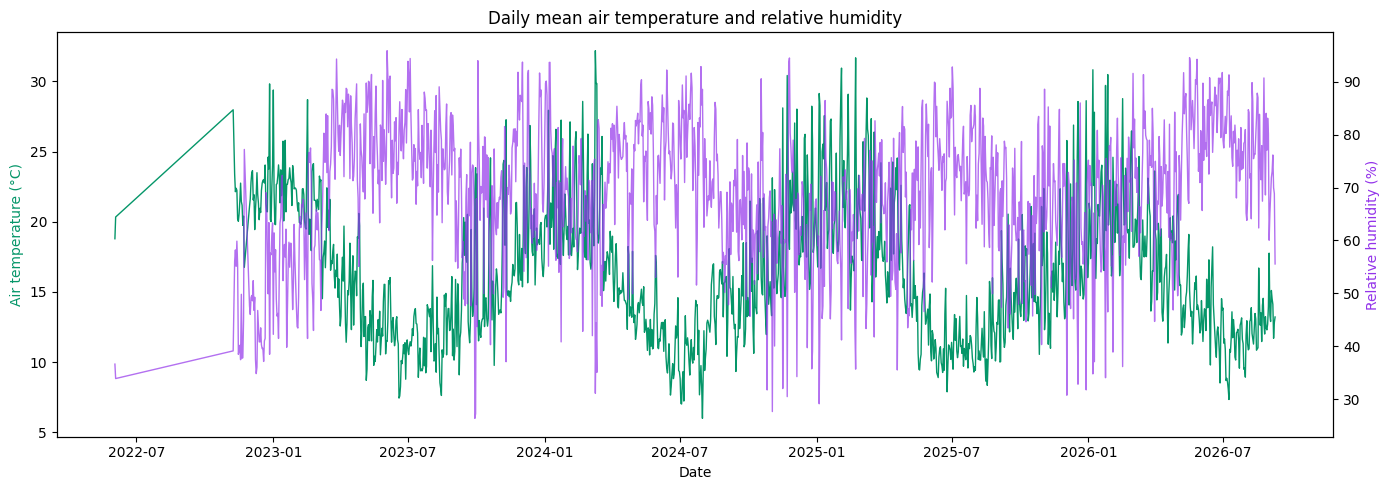

In [7]:
# Daily means make the seasonal signal legible; raw 15-minute readings do not.
daily_climate = (
    mc_clean.set_index("timestamp")[["airtemperature", "relativehumidity"]]
    .resample("D")
    .mean()
    .dropna()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily_climate.index, daily_climate["airtemperature"],
         color=MOP_COLOURS[0], linewidth=1)
ax1.set_xlabel("Date")
ax1.set_ylabel("Air temperature (°C)", color=MOP_COLOURS[0])

ax2 = ax1.twinx()
ax2.plot(daily_climate.index, daily_climate["relativehumidity"],
         color=MOP_COLOURS[1], linewidth=1, alpha=0.7)
ax2.set_ylabel("Relative humidity (%)", color=MOP_COLOURS[1])

plt.title("Daily mean air temperature and relative humidity")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Temperature and humidity move in opposition across the year, which is the expected relationship: warmer air holds more water before saturating, so relative humidity falls as temperature rises. The gap between the two is what drives evaporative demand, and section 5 turns it into a single measure.
</div>

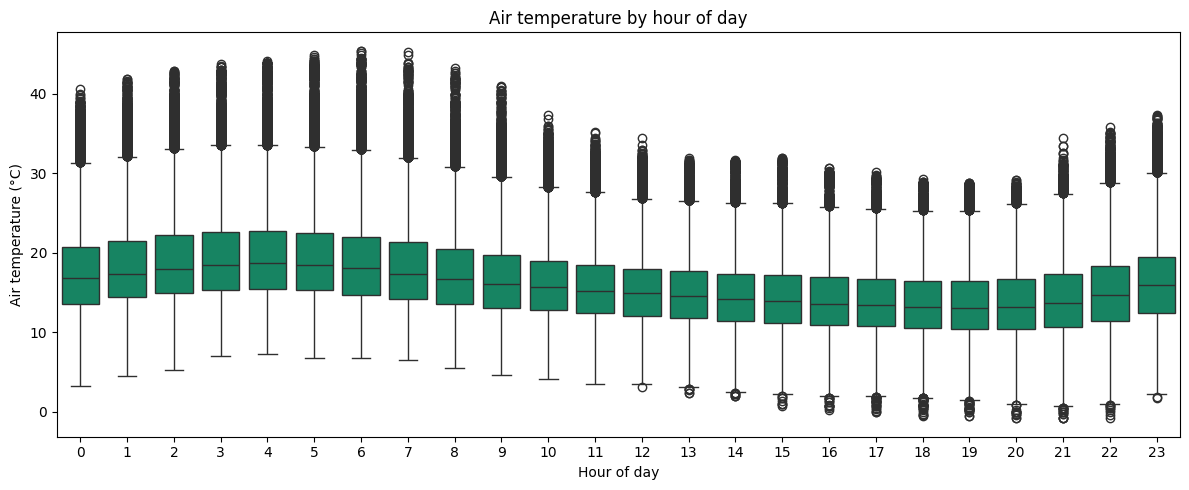

In [8]:
# Temperature by hour of day, pooled across sensors.
hourly = mc_clean.copy()
hourly["hour"] = hourly["timestamp"].dt.hour

plt.figure(figsize=(12, 5))
sns.boxplot(x="hour", y="airtemperature", data=hourly, color=MOP_COLOURS[0])
plt.title("Air temperature by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Air temperature (°C)")
plt.tight_layout()
plt.show()

<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2 Soil moisture patterns</b></div>

<div class="usecase-body">
Soil moisture is bounded between zero and saturation and tends to be multi-modal across sites, because different soil types and irrigation regimes hold water differently. The distribution below pools every site, so its shape reflects the mix of sites as much as any physical property.
</div>

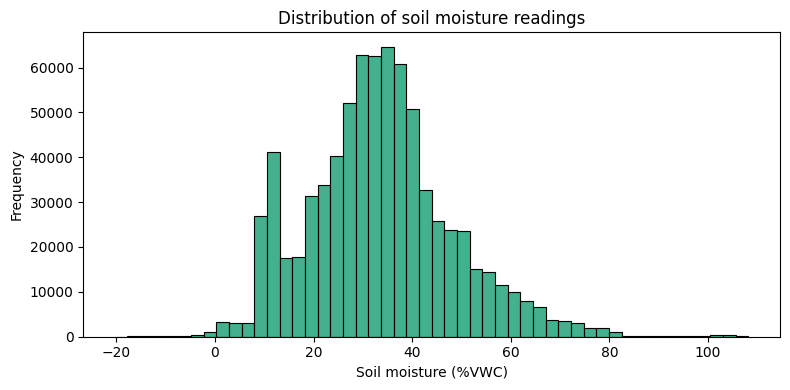

count    761817.00
mean         33.50
std          14.74
min         -20.29
25%          24.12
50%          33.01
75%          41.27
max         108.16


In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(soil_clean["soil_value"], bins=50, color=MOP_COLOURS[0])
plt.title("Distribution of soil moisture readings")
plt.xlabel("Soil moisture (%VWC)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(soil_clean["soil_value"].describe().round(2).to_string())

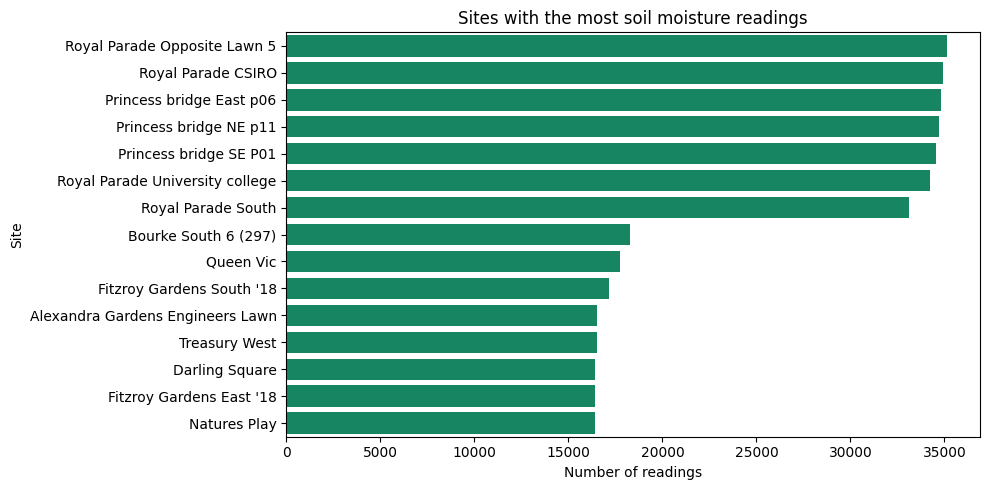

In [10]:
# Which sites contribute the most observations.
# The readings already carry site_name, so no merge is needed here.
site_counts = soil_clean["site_name"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(y=site_counts.index, x=site_counts.values, color=MOP_COLOURS[0])
plt.title("Sites with the most soil moisture readings")
plt.xlabel("Number of readings")
plt.ylabel("Site")
plt.tight_layout()
plt.show()

<div class="usecase-body">
Observations are not spread evenly across sites. A handful of locations contribute a large share of the readings, which matters later: any city-wide average is weighted towards those sites unless the analysis aggregates per site first.
</div>

<div id="subsection-3-3" class="usecase-sub-section-heading"><b>3.3 Correlation structure</b></div>

<div class="usecase-body">
Correlations among the microclimate variables show which measurements carry overlapping information. Strongly correlated inputs are not necessarily a problem for a tree-based model, but they do make feature importances harder to interpret, since the model can substitute one for another.
</div>

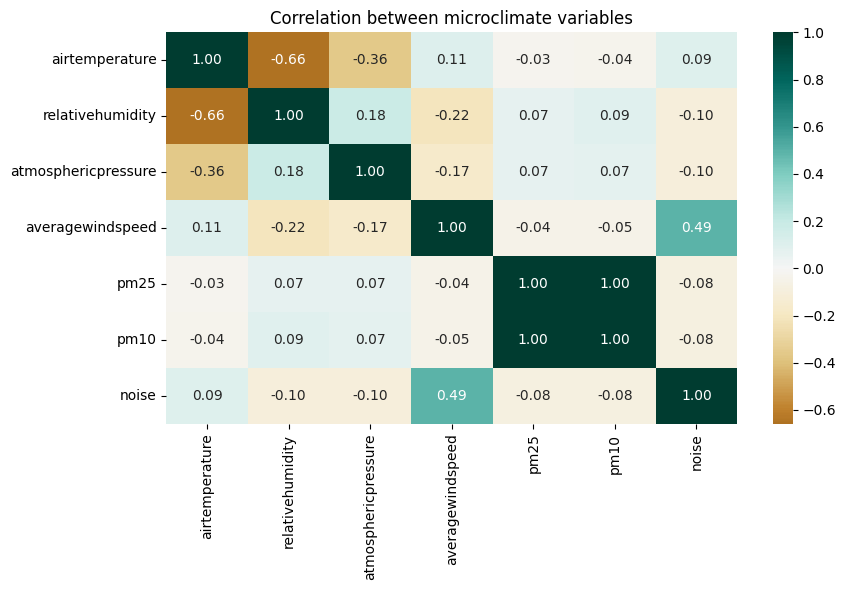

In [11]:
climate_vars = ["airtemperature", "relativehumidity", "atmosphericpressure",
                "averagewindspeed", "pm25", "pm10", "noise"]
available = [c for c in climate_vars if c in mc_clean.columns]

plt.figure(figsize=(9, 6))
sns.heatmap(mc_clean[available].corr(), annot=True, fmt=".2f", cmap="BrBG", center=0)
plt.title("Correlation between microclimate variables")
plt.tight_layout()
plt.show()

<div id="section-4" class="usecase-section-heading"><b>4. Linking microclimate readings to soil sites</b></div>

<div class="usecase-body">
This is the step the whole analysis depends on. The two networks share no common identifier: soil sites are named after parks and garden beds, microclimate sensors after streets, poles and rooftops. Matching the two name fields as exact strings produces a single match across the entire city, which is why this notebook previously analysed one location while describing itself as city-wide.

The soil readings do carry a <code>site_id</code>, and the soil sensor locations dataset documents that key, so soil readings can be given coordinates exactly. The microclimate readings carry their own coordinates. With both sides geocoded, each soil site can be matched to its nearest sensor.
</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1 Choosing which sensors to use</b></div>

<div class="usecase-body">
Not every live sensor is a sensible pairing. Several are mounted on rooftops, which measure the air above a building rather than the conditions at ground level in a garden bed. Since the question here is about the microclimate a soil site actually experiences, rooftop sensors are excluded even where they happen to be the closest.

This costs coverage and is worth being explicit about, because it is a judgement rather than a rule: proximity alone does not make two measurements comparable.
</div>

In [12]:
# One row per sensor, using the median of its reported coordinates.
sensors = (
    mc_clean.groupby("sensorlocation")[["latitude", "longitude"]]
    .median()
    .reset_index()
)

# Rooftop sensors measure air above a building, not conditions in a garden bed.
is_rooftop = sensors["sensorlocation"].str.contains("rooftop", case=False, na=False)

print("Sensors excluded as rooftop-mounted:")
for name in sensors.loc[is_rooftop, "sensorlocation"]:
    print(f"  - {name}")

ground_sensors = sensors.loc[~is_rooftop].reset_index(drop=True)

print(f"\nGround-level sensors retained: {len(ground_sensors)} of {len(sensors)}")
print(ground_sensors.to_string(index=False))

Sensors excluded as rooftop-mounted:
  - 101 Collins St L11 Rooftop
  - CH1 rooftop
  - SkyFarm (Jeff’s Shed). Rooftop - Melbourne Conference & Exhibition Centre (MCEC)

Ground-level sensors retained: 8 of 11
                                                         sensorlocation   latitude  longitude
                                                       1 Treasury Place -37.812888 144.975086
                                                            Batman Park -37.822183 144.956222
                                        Birrarung Marr Park - Pole 1131 -37.818593 144.971640
                                     Enterprize Park - Pole ID: COM1667 -37.820408 144.959119
                                           Royal Park Asset ID: COM2707 -37.795617 144.951901
Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station -37.818452 144.967847
      Tram Stop 7B – Melbourne Tennis Centre Precinct – Rod Laver Arena -37.819499 144.978721
      Tram Stop 7C – Melbourne Tennis C

<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2 Nearest-sensor join</b></div>

<div class="usecase-body">
Distances are computed with the haversine formula, which measures great-circle distance on a sphere. Over a few kilometres the difference between this and a projected coordinate system is negligible, and it avoids introducing a reprojection step.

A one-kilometre threshold is applied. Sites further than that from any ground-level sensor are dropped rather than paired with a sensor that is not describing their conditions. The number of sites retained is printed below and should be read as a statement about sensor coverage, not about the data quality of either network.
</div>

In [13]:
MAX_DISTANCE_KM = 1.0


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres between one point and an array of points."""
    radius = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))


# Match every soil site to its nearest ground-level sensor.
sites = soil_sites.dropna(subset=["latitude", "longitude"]).copy()
sites["latitude"] = pd.to_numeric(sites["latitude"], errors="coerce")
sites["longitude"] = pd.to_numeric(sites["longitude"], errors="coerce")
sites = sites.dropna(subset=["latitude", "longitude"])

matches = []
for _, site in sites.iterrows():
    distances = haversine_km(site["latitude"], site["longitude"],
                             ground_sensors["latitude"].values,
                             ground_sensors["longitude"].values)
    nearest = int(np.argmin(distances))
    matches.append({
        "site_id": site["site_id"],
        "site_name": site["site_name"],
        "property_name": site.get("property_name"),
        "sensorlocation": ground_sensors.iloc[nearest]["sensorlocation"],
        "distance_km": round(float(distances[nearest]), 3),
    })

site_sensor = pd.DataFrame(matches)
within_range = site_sensor[site_sensor["distance_km"] <= MAX_DISTANCE_KM].copy()

print(f"Soil sites total: {len(site_sensor)}")
print(f"Within {MAX_DISTANCE_KM} km of a ground-level sensor: {len(within_range)}")
print(f"Distinct sensors used: {within_range['sensorlocation'].nunique()}")
print(f"Distinct parks covered: {within_range['property_name'].nunique()}")
print(f"\nMedian pairing distance: {within_range['distance_km'].median():.3f} km")
print(f"Maximum pairing distance: {within_range['distance_km'].max():.3f} km")

Soil sites total: 84
Within 1.0 km of a ground-level sensor: 50
Distinct sensors used: 6
Distinct parks covered: 11

Median pairing distance: 0.575 km
Maximum pairing distance: 0.979 km


In [14]:
# For comparison: what the previous name-based join achieved.
name_matches = set(soil_sites["site_name"].dropna()) & set(sensors["sensorlocation"].dropna())
print(f"Sites matched by exact name: {len(name_matches)}")
for name in sorted(name_matches):
    print(f"  - {name}")
print(f"\nSites matched spatially within {MAX_DISTANCE_KM} km: {len(within_range)}")

Sites matched by exact name: 1
  - Batman Park

Sites matched spatially within 1.0 km: 50


<div class="usecase-body">
Of the 84 soil sites, 50 sit within a kilometre of a ground-level microclimate sensor, drawing on 6 sensors across 11 parks and gardens. The single exact name match printed above is what the earlier version of this notebook joined on, which means everything downstream of it described one location while presenting itself as a city-wide analysis.

The 34 sites that fall outside the threshold are not bad data. They are sites the sensor network does not currently cover, mostly in the northern half of Royal Park and around the Shrine, and reporting them as excluded is more useful than pairing them with a sensor two kilometres away.
</div>

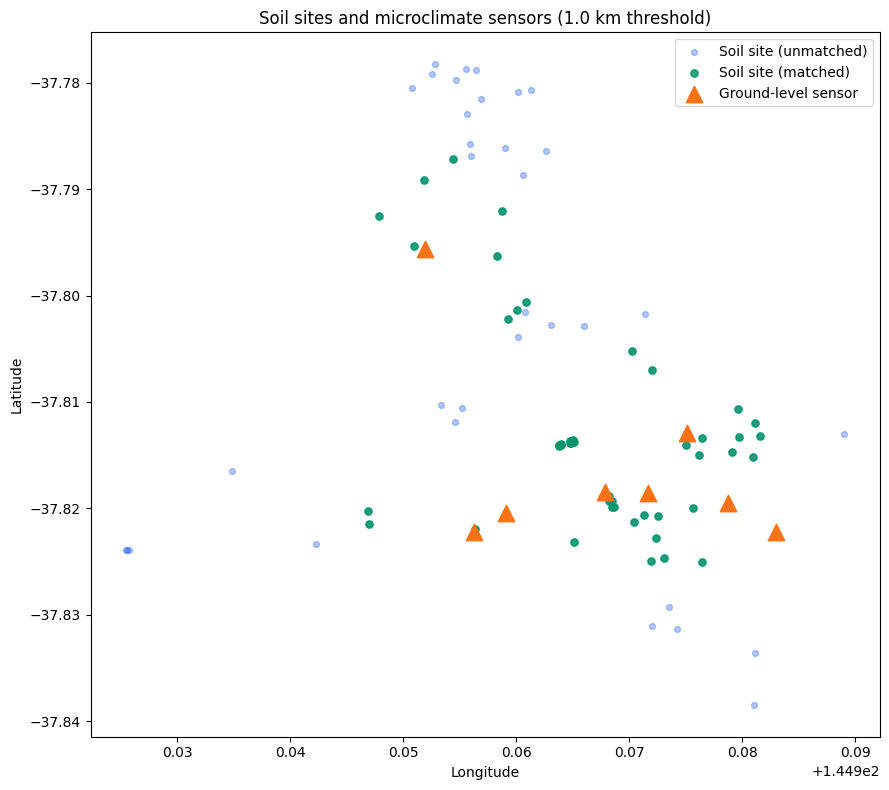

In [15]:
# Map of the retained pairings.
plt.figure(figsize=(9, 8))
plt.scatter(sites["longitude"], sites["latitude"],
            s=18, alpha=0.35, color=MOP_COLOURS[3], label="Soil site (unmatched)")
matched_sites = sites[sites["site_id"].isin(within_range["site_id"])]
plt.scatter(matched_sites["longitude"], matched_sites["latitude"],
            s=28, alpha=0.85, color=MOP_COLOURS[0], label="Soil site (matched)")
plt.scatter(ground_sensors["longitude"], ground_sensors["latitude"],
            s=140, marker="^", color=MOP_COLOURS[2], label="Ground-level sensor")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Soil sites and microclimate sensors ({MAX_DISTANCE_KM} km threshold)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Restrict the soil readings to the matched sites before any heavy processing.
# site_name is already present in the readings. Taking it from the locations
# side as well would produce site_name_x and site_name_y.
soil_matched = soil_clean.merge(
    within_range[["site_id", "property_name", "sensorlocation", "distance_km"]],
    on="site_id",
    how="inner",
)

print(f"Soil readings retained: {len(soil_matched):,} of {len(soil_clean):,} "
      f"({100 * len(soil_matched) / len(soil_clean):.1f}%)")
print(f"Sites represented: {soil_matched['site_id'].nunique()}")

Soil readings retained: 502,362 of 761,817 (65.9%)
Sites represented: 41


<div id="section-5" class="usecase-section-heading"><b>5. Feature engineering</b></div>

<div class="usecase-body">
Both networks report far more often than daily. Aggregating to daily values per site and per sensor gives a common resolution to join on, and daily is the right scale for the question, since soil moisture responds to accumulated conditions rather than to individual fifteen-minute readings.
</div>

<div id="subsection-5-1" class="usecase-sub-section-heading"><b>5.1 Microclimate features</b></div>

<div class="usecase-body">
Vapour-pressure deficit combines temperature and humidity into a single measure of how strongly the atmosphere is pulling moisture out of soil and plants. It is a better predictor of drying than either input alone, because the same humidity means very different things at 15°C and at 35°C.

Rolling seven-day means capture accumulated conditions, since a single hot day matters less than a hot week.
</div>

In [17]:
def vapour_pressure_deficit(temp_c, relative_humidity):
    """
    Vapour-pressure deficit in kPa.

    Saturation vapour pressure follows the Tetens approximation; actual vapour
    pressure is that value scaled by relative humidity. The difference is how
    much more water the air could hold, which is what drives evaporation.
    """
    saturation = 0.6108 * np.exp((17.27 * temp_c) / (temp_c + 237.3))
    actual = saturation * (relative_humidity / 100.0)
    return saturation - actual


mc_features = mc_clean.copy()
mc_features["vpd_kpa"] = vapour_pressure_deficit(
    mc_features["airtemperature"], mc_features["relativehumidity"]
)
mc_features["date"] = mc_features["timestamp"].dt.date

# Daily summary per sensor.
climate_daily = (
    mc_features.groupby(["sensorlocation", "date"])
    .agg(
        air_temp=("airtemperature", "mean"),
        air_temp_max=("airtemperature", "max"),
        humidity=("relativehumidity", "mean"),
        wind_speed=("averagewindspeed", "mean"),
        vpd=("vpd_kpa", "mean"),
    )
    .reset_index()
    .sort_values(["sensorlocation", "date"])
)

# Accumulated conditions matter more than any single day.
for column in ["air_temp", "vpd"]:
    climate_daily[f"{column}_7d"] = (
        climate_daily.groupby("sensorlocation")[column]
        .transform(lambda s: s.rolling(7, min_periods=3).mean())
    )

print(f"Daily climate rows: {len(climate_daily):,}")
print(climate_daily.head().to_string(index=False))

Daily climate rows: 10,482
  sensorlocation       date  air_temp  air_temp_max  humidity  wind_speed      vpd  air_temp_7d   vpd_7d
1 Treasury Place 2024-08-13 15.521053          19.8 75.090526    2.149474 0.475418          NaN      NaN
1 Treasury Place 2024-08-14 16.120833          20.7 76.071875    2.229167 0.477847          NaN      NaN
1 Treasury Place 2024-08-15 16.301042          20.3 71.630208    1.989583 0.554154    15.980976 0.502473
1 Treasury Place 2024-08-16 12.422917          15.6 86.390625    1.931250 0.217235    15.091461 0.431163
1 Treasury Place 2024-08-17 11.928125          14.7 93.145833    1.045833 0.101730    14.458794 0.365277


<div id="subsection-5-2" class="usecase-sub-section-heading"><b>5.2 Soil moisture features</b></div>

<div class="usecase-body">
Soil moisture is aggregated to a daily mean per site. The day-on-day change is computed within each site, so a change is never calculated across two different locations, and a seven-day rolling mean provides the site's recent baseline.
</div>

In [18]:
soil_matched["date"] = soil_matched["timestamp"].dt.date

# Not every site records the park it sits in. pandas drops rows whose group key
# is missing, so leaving these as NaN would silently discard those sites.
soil_matched["property_name"] = soil_matched["property_name"].fillna("(not recorded)")

soil_daily = (
    soil_matched.groupby(["site_id", "site_name", "property_name",
                          "sensorlocation", "date"])
    .agg(soil_moisture=("soil_value", "mean"))
    .reset_index()
    .sort_values(["site_id", "date"])
)

# Confirm no sites were lost between the join and the daily aggregation.
print(f"Sites entering aggregation: {soil_matched['site_id'].nunique()}")
print(f"Sites after aggregation:    {soil_daily['site_id'].nunique()}")

# Differences are computed within a site so they never span two locations.
soil_daily["soil_moisture_change"] = soil_daily.groupby("site_id")["soil_moisture"].diff()
soil_daily["soil_moisture_7d"] = (
    soil_daily.groupby("site_id")["soil_moisture"]
    .transform(lambda s: s.rolling(7, min_periods=3).mean())
)

print(f"Daily soil rows: {len(soil_daily):,}")
print(f"Sites: {soil_daily['site_id'].nunique()}, "
      f"days: {soil_daily['date'].nunique()}")
print(soil_daily.head().to_string(index=False))

Sites entering aggregation: 41
Sites after aggregation:    41
Daily soil rows: 17,075
Sites: 41, days: 678
 site_id              site_name    property_name   sensorlocation       date  soil_moisture  soil_moisture_change  soil_moisture_7d
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2023-12-31      29.305714                   NaN               NaN
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-01      31.911429              2.605714               NaN
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-02      32.585882              0.674454         31.267675
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-03      30.399286             -2.186597         31.050578
   64977 Treasury Gardens South Treasury Gardens 1 Treasury Place 2024-01-04      30.372500             -0.026786         30.914962


In [19]:
# Join each site-day to its paired sensor's conditions for that day.
combined = soil_daily.merge(
    climate_daily,
    on=["sensorlocation", "date"],
    how="inner",
)

print(f"Combined site-days: {len(combined):,}")
print(f"Sites: {combined['site_id'].nunique()}")
print(f"Date range: {combined['date'].min()} to {combined['date'].max()}")
print(f"\nCompare with the single-location join this replaced.")

Combined site-days: 13,022
Sites: 38
Date range: 2023-12-31 to 2026-09-07

Compare with the single-location join this replaced.


<div id="section-6" class="usecase-section-heading"><b>6. Temporal trends</b></div>

<div class="usecase-body">
With sites and conditions aligned, the seasonal relationship between evaporative demand and soil moisture can be examined directly.
</div>

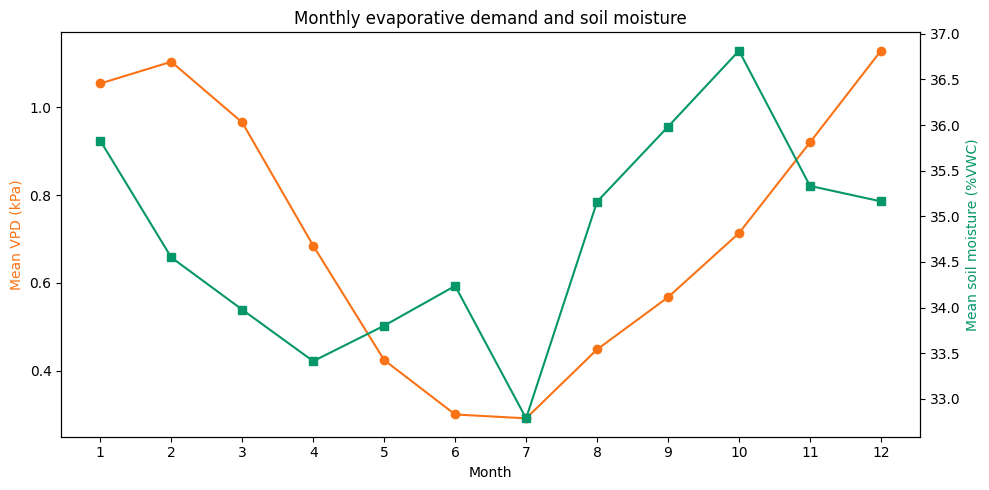

In [20]:
monthly = combined.copy()
monthly["month"] = pd.to_datetime(monthly["date"]).dt.month

monthly_means = monthly.groupby("month").agg(
    vpd=("vpd", "mean"),
    soil_moisture=("soil_moisture", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(monthly_means["month"], monthly_means["vpd"],
         marker="o", color=MOP_COLOURS[2], label="VPD")
ax1.set_xlabel("Month")
ax1.set_ylabel("Mean VPD (kPa)", color=MOP_COLOURS[2])
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(monthly_means["month"], monthly_means["soil_moisture"],
         marker="s", color=MOP_COLOURS[0], label="Soil moisture")
ax2.set_ylabel("Mean soil moisture (%VWC)", color=MOP_COLOURS[0])

plt.title("Monthly evaporative demand and soil moisture")
plt.tight_layout()
plt.show()

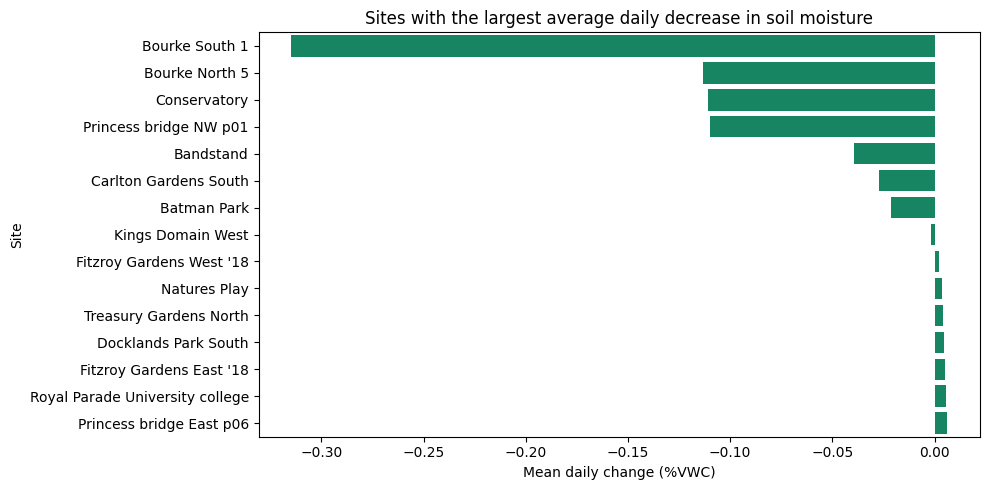

In [21]:
# Which sites dry fastest on average.
drying = (
    combined.groupby("site_name")["soil_moisture_change"]
    .mean()
    .sort_values()
    .head(15)
)

plt.figure(figsize=(10, 5))
sns.barplot(y=drying.index, x=drying.values, color=MOP_COLOURS[0])
plt.title("Sites with the largest average daily decrease in soil moisture")
plt.xlabel("Mean daily change (%VWC)")
plt.ylabel("Site")
plt.tight_layout()
plt.show()

<div id="section-7" class="usecase-section-heading"><b>7. Clustering analysis</b></div>

<div class="usecase-body">
Clustering groups site-days by their combined soil and atmospheric conditions. The aim is descriptive: to see whether recognisable regimes exist, such as hot and dry days at well-drained sites versus mild days at sites that retain water.

Features are standardised first, because k-means measures distance and would otherwise be dominated by whichever variable has the largest numeric range. The number of clusters is chosen by silhouette score rather than assumed.
</div>

In [22]:
cluster_features = ["vpd", "air_temp", "humidity", "soil_moisture", "soil_moisture_change"]
cluster_data = combined.dropna(subset=cluster_features).copy()

X_scaled = StandardScaler().fit_transform(cluster_data[cluster_features])

# Silhouette score across candidate cluster counts.
scores = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels, sample_size=10000,
                                 random_state=RANDOM_SEED)

for k, score in scores.items():
    print(f"  k={k}: silhouette {score:.3f}")

best_k = max(scores, key=scores.get)
print(f"\nSelected k = {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(X_scaled)

  k=2: silhouette 0.306
  k=3: silhouette 0.255
  k=4: silhouette 0.271
  k=5: silhouette 0.284
  k=6: silhouette 0.291
  k=7: silhouette 0.247

Selected k = 2


In [23]:
# Cluster profiles: the mean of each feature within each cluster.
profile = cluster_data.groupby("cluster")[cluster_features].mean().round(2)
profile["n_site_days"] = cluster_data["cluster"].value_counts().sort_index()
print(profile.to_string())

          vpd  air_temp  humidity  soil_moisture  soil_moisture_change  n_site_days
cluster                                                                            
0        0.38     13.18     77.03          34.91                  0.06         8869
1        1.19     20.70     57.69          33.77                 -0.10         4139


<div class="usecase-body">
Two clusters give the best silhouette score, and the split they describe is essentially seasonal. One group is cool and humid with high evaporative demand absent and soil moisture edging upwards; the other is warm and dry with higher vapour-pressure deficit and soil moisture edging down.

What the clusters do not show is a strong separation in soil moisture itself: the mean level differs between the two groups by around a single percentage point of volumetric water content, far less than the difference in air temperature or humidity. The clustering is therefore better read as recovering Melbourne's seasons from the sensor data than as identifying sites that behave differently from one another. Distinguishing sites would need features describing the site itself, such as soil type, canopy cover or irrigation schedule, none of which are in these datasets.
</div>

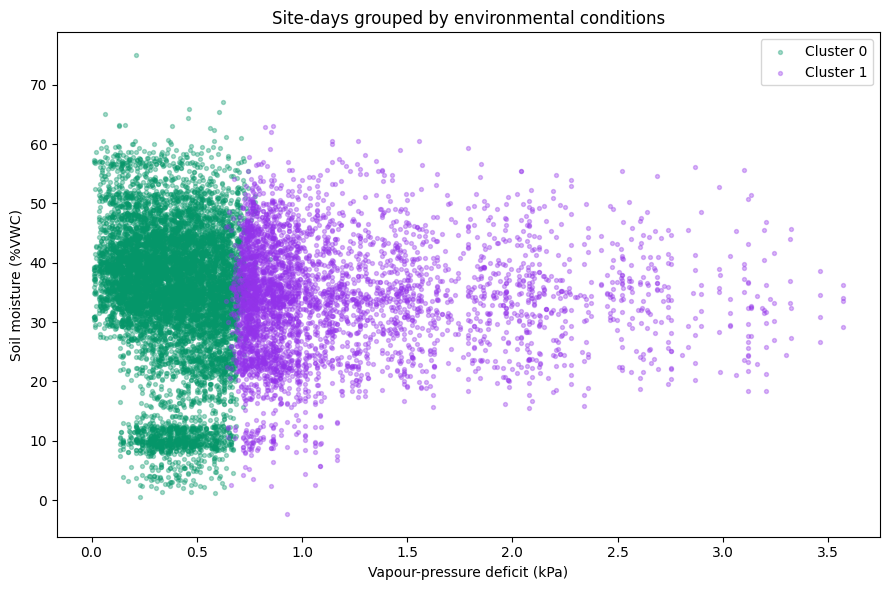

In [24]:
plt.figure(figsize=(9, 6))
for cluster_id in sorted(cluster_data["cluster"].unique()):
    subset = cluster_data[cluster_data["cluster"] == cluster_id]
    plt.scatter(subset["vpd"], subset["soil_moisture"],
                s=8, alpha=0.35,
                color=MOP_COLOURS[cluster_id % len(MOP_COLOURS)],
                label=f"Cluster {cluster_id}")
plt.xlabel("Vapour-pressure deficit (kPa)")
plt.ylabel("Soil moisture (%VWC)")
plt.title("Site-days grouped by environmental conditions")
plt.legend()
plt.tight_layout()
plt.show()

<div id="section-8" class="usecase-section-heading"><b>8. Predicting next-day soil moisture</b></div>

<div class="usecase-body">
The modelling question is whether today's conditions carry information about tomorrow's soil moisture at the same site.

Two design decisions matter more than the choice of algorithm. First, the train/test split must respect time: soil moisture is highly autocorrelated, so a random split would place a Tuesday in training and the adjacent Wednesday in testing, and the model would score well by memorising rather than generalising. Second, the model must be compared against a baseline that costs nothing, because soil moisture changes slowly and 'tomorrow will look like today' is already a strong prediction.
</div>

In [25]:
model_data = combined.sort_values(["site_id", "date"]).copy()

# Tomorrow's soil moisture at the same site.
model_data["target"] = model_data.groupby("site_id")["soil_moisture"].shift(-1)

FEATURES = [
    "soil_moisture", "soil_moisture_change", "soil_moisture_7d",
    "vpd", "vpd_7d", "air_temp", "air_temp_max", "air_temp_7d",
    "humidity", "wind_speed",
]

model_data = model_data.dropna(subset=FEATURES + ["target"])
model_data["date"] = pd.to_datetime(model_data["date"])

# Chronological split: the last 20% of the calendar is held out.
split_date = model_data["date"].quantile(0.8)
train = model_data[model_data["date"] <= split_date]
test = model_data[model_data["date"] > split_date]

print(f"Train: {len(train):,} site-days, up to {split_date.date()}")
print(f"Test:  {len(test):,} site-days, after {split_date.date()}")

Train: 10,352 site-days, up to 2025-06-25
Test:  2,581 site-days, after 2025-06-25


<div id="subsection-8-1" class="usecase-sub-section-heading"><b>8.1 Persistence baseline</b></div>

<div class="usecase-body">
The persistence baseline predicts that tomorrow's soil moisture equals today's. It requires no model at all, and any model that cannot beat it is not adding value. Reporting it alongside the model is what turns an accuracy figure into evidence.
</div>

In [26]:
baseline_pred = test["soil_moisture"]
baseline_rmse = mean_squared_error(test["target"], baseline_pred) ** 0.5
baseline_mae = mean_absolute_error(test["target"], baseline_pred)
baseline_r2 = r2_score(test["target"], baseline_pred)

print("Persistence baseline (tomorrow = today)")
print(f"  RMSE: {baseline_rmse:.3f}")
print(f"  MAE:  {baseline_mae:.3f}")
print(f"  R2:   {baseline_r2:.3f}")

Persistence baseline (tomorrow = today)
  RMSE: 1.628
  MAE:  0.681
  R2:   0.981


<div id="subsection-8-2" class="usecase-sub-section-heading"><b>8.2 Random Forest model</b></div>

<div class="usecase-body">
The Random Forest is given the same information a person would have on the day: the site's current and recent soil moisture, and the conditions its paired sensor recorded. Performance is reported against the baseline above.
</div>

In [27]:
model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
model.fit(train[FEATURES], train["target"])

predictions = model.predict(test[FEATURES])
model_rmse = mean_squared_error(test["target"], predictions) ** 0.5
model_mae = mean_absolute_error(test["target"], predictions)
model_r2 = r2_score(test["target"], predictions)

print("Random Forest")
print(f"  RMSE: {model_rmse:.3f}")
print(f"  MAE:  {model_mae:.3f}")
print(f"  R2:   {model_r2:.3f}")
print()
print("Change against the persistence baseline (positive means the model is better):")
print(f"  RMSE: {100 * (baseline_rmse - model_rmse) / baseline_rmse:+.1f}%")
print(f"  MAE:  {100 * (baseline_mae - model_mae) / baseline_mae:+.1f}%")

if model_rmse < baseline_rmse:
    print("\nThe model improves on simply carrying yesterday's reading forward.")
else:
    print("\nThe model does not beat carrying yesterday's reading forward.")

Random Forest
  RMSE: 1.867
  MAE:  1.080
  R2:   0.975

Change against the persistence baseline (positive means the model is better):
  RMSE: -14.7%
  MAE:  -58.5%

The model does not beat carrying yesterday's reading forward.


<div class="usecase-body">
The Random Forest does not beat the persistence baseline. Both approaches produce a high R², which is the point worth pausing on: an R² above 0.9 here reflects how little soil moisture moves overnight, not how well the model has learned anything. Had this notebook reported the model's R² alone, it would have looked like a strong result while actually performing worse than doing nothing.

The feature importances show what the model relied on. Almost all of the weight sits on the site's own recent soil moisture, and the microclimate features together account for a small fraction. The model is effectively a smoothed version of persistence, and smoothing costs accuracy when the underlying series is already close to a random walk.
</div>

<div id="subsection-8-3" class="usecase-sub-section-heading"><b>8.3 Feature importance</b></div>

<div class="usecase-body">
Feature importances show which inputs the model relied on. They should be read with the correlation structure from section 3.3 in mind: where two inputs carry similar information, the model may lean on one and appear to ignore the other.
</div>

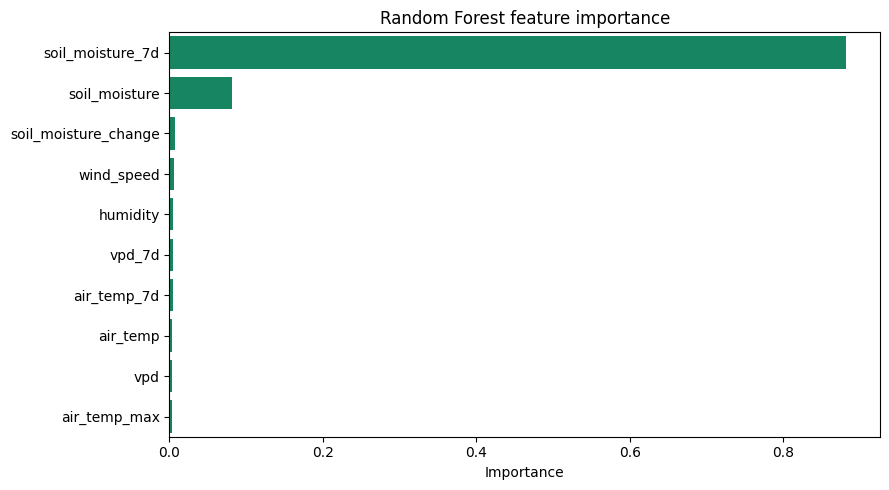

soil_moisture_7d        0.8822
soil_moisture           0.0819
soil_moisture_change    0.0077
wind_speed              0.0055
humidity                0.0043
vpd_7d                  0.0043
air_temp_7d             0.0040
air_temp                0.0035
vpd                     0.0034
air_temp_max            0.0032


In [28]:
importances = (
    pd.Series(model.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, color=MOP_COLOURS[0])
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(importances.round(4).to_string())

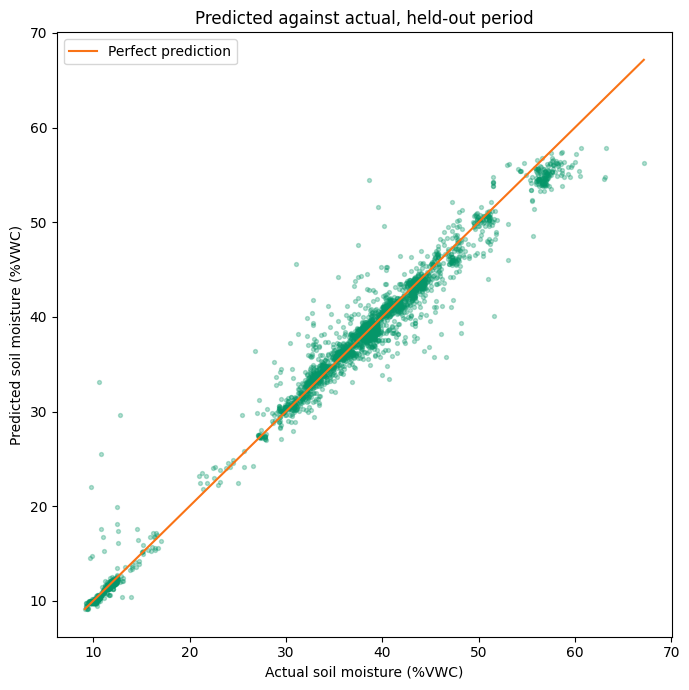

In [29]:
# Predicted against actual on the held-out period.
plt.figure(figsize=(7, 7))
plt.scatter(test["target"], predictions, s=8, alpha=0.3, color=MOP_COLOURS[0])
limits = [test["target"].min(), test["target"].max()]
plt.plot(limits, limits, color=MOP_COLOURS[2], linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual soil moisture (%VWC)")
plt.ylabel("Predicted soil moisture (%VWC)")
plt.title("Predicted against actual, held-out period")
plt.legend()
plt.tight_layout()
plt.show()

<div id="subsection-8-4" class="usecase-sub-section-heading"><b>8.4 Predicting the day-to-day change</b></div>

<div class="usecase-body">
Section 8.2 asked whether the model could predict tomorrow's soil moisture level, and persistence won. That comparison is dominated by autocorrelation: soil moisture moves slowly, so most of what the model had to predict was already contained in today's reading.

A more revealing question is whether the atmospheric conditions predict the <i>change</i>. Here the target becomes the difference between tomorrow and today, and the baseline becomes the assumption that nothing changes. This is a much harder target and a low R² should be expected. What matters is whether the microclimate features explain any of the variation at all.
</div>

In [30]:
# Same features and the same chronological split; only the target changes.
change_train = train.copy()
change_test = test.copy()
change_train["target_change"] = change_train["target"] - change_train["soil_moisture"]
change_test["target_change"] = change_test["target"] - change_test["soil_moisture"]

# The no-change baseline predicts zero movement.
no_change = np.zeros(len(change_test))
base_change_rmse = mean_squared_error(change_test["target_change"], no_change) ** 0.5
base_change_mae = mean_absolute_error(change_test["target_change"], no_change)
base_change_r2 = r2_score(change_test["target_change"], no_change)

print("No-change baseline")
print(f"  RMSE: {base_change_rmse:.3f}")
print(f"  MAE:  {base_change_mae:.3f}")
print(f"  R2:   {base_change_r2:.3f}")

No-change baseline
  RMSE: 1.628
  MAE:  0.681
  R2:   -0.000


In [31]:
change_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
change_model.fit(change_train[FEATURES], change_train["target_change"])

change_pred = change_model.predict(change_test[FEATURES])
change_rmse = mean_squared_error(change_test["target_change"], change_pred) ** 0.5
change_mae = mean_absolute_error(change_test["target_change"], change_pred)
change_r2 = r2_score(change_test["target_change"], change_pred)

print("Random Forest predicting the change")
print(f"  RMSE: {change_rmse:.3f}")
print(f"  MAE:  {change_mae:.3f}")
print(f"  R2:   {change_r2:.3f}")
print()
print("Change against the no-change baseline (positive means the model is better):")
print(f"  RMSE: {100 * (base_change_rmse - change_rmse) / base_change_rmse:+.1f}%")
print(f"  MAE:  {100 * (base_change_mae - change_mae) / base_change_mae:+.1f}%")

Random Forest predicting the change
  RMSE: 1.743
  MAE:  0.946
  R2:   -0.147

Change against the no-change baseline (positive means the model is better):
  RMSE: -7.1%
  MAE:  -38.8%


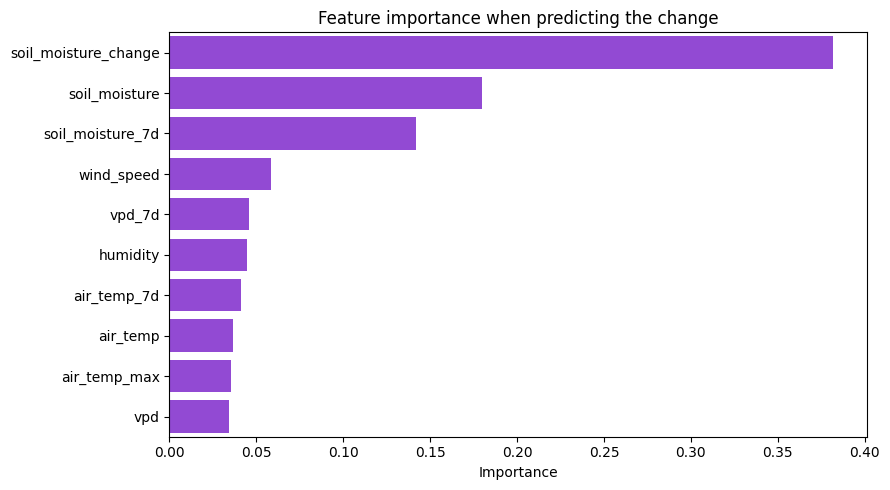

soil_moisture_change    0.3820
soil_moisture           0.1801
soil_moisture_7d        0.1419
wind_speed              0.0583
vpd_7d                  0.0458
humidity                0.0443
air_temp_7d             0.0413
air_temp                0.0363
air_temp_max            0.0357
vpd                     0.0343


In [32]:
# Which features carry information about the change, as distinct from the level.
change_importances = (
    pd.Series(change_model.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=change_importances.values, y=change_importances.index,
            color=MOP_COLOURS[1])
plt.title("Feature importance when predicting the change")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(change_importances.round(4).to_string())

<div class="usecase-body">
Comparing the two importance rankings is the useful part. Predicting the level, the model leaned almost entirely on the site's own recent soil moisture and the atmospheric features barely registered. Predicting the change, that ordering shifts considerably: wind speed, vapour-pressure deficit and humidity all take on real weight, together accounting for a substantial share of the model's decisions.

Even so, the model does not beat the no-change baseline, and its R² on the change is negative, meaning it performs worse than predicting the average change for every day. So the microclimate conditions are not meaningless here, they are simply outweighed by something the data does not contain.

That something is almost certainly water arriving at the site. Rainfall and irrigation are the two largest inputs to soil moisture and neither is recorded in these datasets, so a day when the sprinklers ran and a day when they did not look identical to this model. Read this result as locating the missing variable rather than as a failure of the method.
</div>

<div class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">
This use case joined two independently operated sensor networks that share no common identifier, and used the combined data to describe how atmospheric conditions relate to soil moisture across the City of Melbourne's parks and gardens.
</div>

**What we achieved in this analysis**

We linked two independently operated sensor networks that share no common identifier, using the documented site identifier to give soil readings their coordinates and a nearest-sensor spatial join to pair each site with the ground-level microclimate sensor closest to it. We derived vapour-pressure deficit and rolling-window features, grouped site-days into environmental regimes with k-means, and tested whether a Random Forest could predict next-day soil moisture, first as a level and then as a change.

**What we learned from this analysis**

The join method determined what the analysis could honestly claim. Matching the two networks by name yields exactly one site out of 84, so an analysis built on that join describes a single park while appearing to describe the city. Matching spatially, with a stated distance threshold and rooftop sensors excluded, covers 50 sites across 11 parks and makes the limits of sensor coverage visible instead of hidden.

The modelling taught the same lesson about comparison. Soil moisture changes slowly, so any model handed yesterday's reading will report a high R². Only the persistence baseline reveals that the model is in fact doing worse than carrying yesterday's value forward, and only reframing the target as the day-to-day change gives the atmospheric features a fair test. On that harder target the microclimate variables carry noticeably more weight, but still not enough to beat assuming no change at all.

The clustering was similarly instructive. Two clear groups emerge, but they separate warm dry conditions from cool humid ones rather than distinguishing sites, which is a seasonal signal rather than a site-level one.

**Observations for further opportunities**

Rainfall is the clearest gap. It is the largest single input to soil moisture, it is absent from both datasets, and its absence is the most likely explanation for the unexplained day-to-day variation. Bureau of Meteorology daily records would be straightforward to join on date and would likely change the modelling results substantially. Irrigation schedules, if the council holds them, would account for much of the remainder.

Sensor coverage is the second constraint. A small number of ground-level microclimate sensors serve a much larger number of soil sites, and 34 of the 84 sites have no sensor within a kilometre. Denser instrumentation in the parks, particularly in the northern half of Royal Park, would extend this analysis considerably.

Finally, site characteristics would help. Soil type, canopy cover and aspect would give a model some basis for distinguishing a site that dries quickly because of its soil from one that dries quickly because of its exposure, which nothing in the current feature set can separate.